<a href="https://colab.research.google.com/github/jwookkim0512/machinelearning-assignments/blob/main/%EA%B8%B0%EB%A7%90%EA%B3%A0%EC%82%AC20250613.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **기말고사(20250613)**
학번 : 2021142009
성명 : 김재욱

# **문제 1) ANN Backpropagation**

In [ ]:
# Back-propagation of ANN with numpy (수작업 버전, 4-hidden)
import numpy as np
import matplotlib.pyplot as plt

# Data Generation
np.random.seed(0)
num_samples = 300
x1 = np.random.uniform(0, 1, num_samples)
x2 = np.random.uniform(0, 1, num_samples)
x3 = np.random.uniform(0, 1, num_samples)

y = 3 * x1 - 2 * x2 + x3  # Target (선형 조합)
Input = np.column_stack((x1, x2, x3))  # shape (300, 3)

# Sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

# Network structure
input_layer_size = 3
hidden_layer_size = 4
output_layer_size = 1

# Weight & bias initialization
W1 = np.random.rand(hidden_layer_size, input_layer_size)
b1 = np.random.rand(hidden_layer_size)
W2 = np.random.rand(output_layer_size, hidden_layer_size)
b2 = np.random.rand(output_layer_size)

alpha = 1e-3  # learning rate
epochs = 100

MSE_list, MAPE_list = [], []

# Training loop
for epoch in range(epochs):
    MSE, MAPE = 0, 0
    for iter in range(num_samples):
        X = Input[iter]

        # Feedforward
        Z_tilde = W1 @ X.reshape(-1,1) + b1.reshape(-1,1)  # shape (4,1)
        Z = sigmoid(Z_tilde)
        y_pred = W2 @ Z + b2.reshape(-1,1)  # shape (1,1)

        # Loss
        J = 0.5 * (y_pred - y[iter])**2
        MSE += J
        MAPE += np.abs((y_pred - y[iter]) / y[iter]) * 100

        # Backpropagation
        dJdY = (y_pred - y[iter])  # shape (1,1)

        # W2 gradients
        dJdW2 = dJdY * Z.T         # shape (1,4)
        dJdb2 = dJdY

        # W1, b1 gradients per hidden node (4 nodes)
        dJdZ = (dJdY @ W2).reshape(-1, 1)  # shape (4,1)
        dZdz = sigmoid_derivative(Z_tilde)  # shape (4,1)
        delta = dJdZ * dZdz  # shape (4,1)

        dJdW1 = delta @ X.reshape(1, -1)  # shape (4,3)
        dJdb1 = delta.reshape(-1)        # shape (4,)

        # Update parameters
        W2 -= alpha * dJdW2
        b2 -= alpha * dJdb2.reshape(-1)

        W1 -= alpha * dJdW1
        b1 -= alpha * dJdb1

    # Epoch 평균 손실 저장
    MSE /= num_samples
    MAPE /= num_samples
    MSE_list.append(np.squeeze(MSE))
    MAPE_list.append(np.squeeze(MAPE))

    if epoch % 5 == 0 or epoch == epochs-1:
        print(f'Epoch {epoch} - MSE: {np.squeeze(MSE):.4f}, MAPE: {np.squeeze(MAPE):.2f}%')

# Plotting
plt.figure()
plt.plot(np.arange(1, epochs+1), MSE_list, label='MSE', linewidth=1.5, color='b')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('MSE by Epoch')
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(np.arange(1, epochs+1), MAPE_list, label='MAPE', linewidth=1.5, color='r')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Percentage Error (%)')
plt.title('MAPE by Epoch')
plt.grid(True)
plt.legend()
plt.show()


Epoch 0 - MSE: 0.8210, MAPE: 488.08%
Epoch 5 - MSE: 0.6002, MAPE: 305.41%
Epoch 10 - MSE: 0.5967, MAPE: 303.67%
Epoch 15 - MSE: 0.5931, MAPE: 302.97%
Epoch 20 - MSE: 0.5893, MAPE: 302.23%
Epoch 25 - MSE: 0.5854, MAPE: 301.41%
Epoch 30 - MSE: 0.5811, MAPE: 300.49%
Epoch 35 - MSE: 0.5763, MAPE: 299.45%
Epoch 40 - MSE: 0.5710, MAPE: 298.24%
Epoch 45 - MSE: 0.5650, MAPE: 296.82%
Epoch 50 - MSE: 0.5580, MAPE: 295.16%
Epoch 55 - MSE: 0.5500, MAPE: 293.18%
Epoch 60 - MSE: 0.5407, MAPE: 290.83%
Epoch 65 - MSE: 0.5298, MAPE: 288.02%
Epoch 70 - MSE: 0.5170, MAPE: 284.65%


# **문제 2) CNN**
- Data
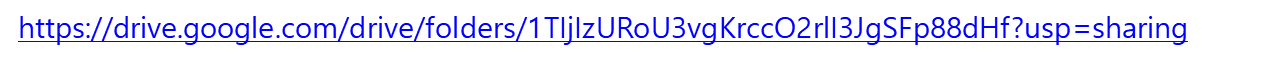

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# 0,1,2,3,4, and 5 finger image data set

train_x = np.load('/content/drive/MyDrive/Finger_train_img.npy')
train_y = np.load('/content/drive/MyDrive/Finger_train_label.npy')

test_x = np.load('/content/drive/MyDrive/Finger_test_img.npy')
test_y = np.load('/content/drive/MyDrive/Finger_test_label.npy')

# **문제 3) K-means clustering**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
data1 = np.array((np.random.normal(0, 0.2, 100), np.random.normal(0.0, 0.4, 100)))
data2 = np.array((np.random.normal(1.2, 0.3, 100), np.random.normal(1.1, 0.7, 100)))
data3 = np.array((np.random.normal(1.6, 0.2, 100), np.random.normal(1.8, 0.7, 100)))
data4 = np.array((np.random.normal(0.3, 0.1, 100), np.random.normal(0.5, 0.3, 100)))